<a href="https://colab.research.google.com/github/precious95/CBCloudAI/blob/main/cnn_downscale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

In [ ]:
os.getcwd()

'/content'

In [ ]:
os.chdir('/content/drive/MyDrive/deep4')

In [ ]:
!pip install xarray

In [ ]:
!pip install captum

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 43.4 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade xarray torch captum



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.1.2
    Uninstalling xarray-2025.1.2:
      Successfully uninstalled xarray-2025.1.2


In [ ]:
!pip install xarray[complete]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.8/48.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.3/147.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.4/196.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
import xarray as xr

In [ ]:
import torch
import captum
from torch.utils.data import DataLoader, random_split


In [ ]:
!pip install xskillscore

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 2.9 MB/s eta 0:00:00


In [ ]:
import deep4downscaling.viz
import deep4downscaling.trans
import deep4downscaling.deep.loss
import deep4downscaling.deep.utils
import deep4downscaling.deep.models
import deep4downscaling.deep.train
import deep4downscaling.deep.pred
import deep4downscaling.metrics
import deep4downscaling.metrics_ccs


In [ ]:
#predictor_filename = 'pred2.nc'
predictor_filename = 'pred_era5.nc'
predictor = xr.open_dataset(predictor_filename)

# Load predictand
predictand_filename = '10km_tmin.nc'
predictand = xr.open_dataset(predictand_filename)
# Split data into training and test sets
years_train = ('1983', '2010')
years_test = ('2011', '2015')


In [ ]:
predictor = predictor.rename({'valid_time': 'time'})


In [ ]:
predictor = predictor.squeeze(drop=True)




In [ ]:
predictor

<xarray.Dataset> Size: 359MB
Dimensions:  (time: 12053, lon: 31, lat: 16)
Coordinates:
  * time     (time) datetime64[ns] 96kB 1983-01-01 1983-01-02 ... 2015-12-31
  * lon      (lon) float64 248B -30.0 -28.0 -26.0 -24.0 ... 24.0 26.0 28.0 30.0
  * lat      (lat) float64 128B 0.0 2.0 4.0 6.0 8.0 ... 22.0 24.0 26.0 28.0 30.0
Data variables: (12/15)
    q500     (time, lat, lon) float32 24MB ...
    q700     (time, lat, lon) float32 24MB ...
    q850     (time, lat, lon) float32 24MB ...
    t500     (time, lat, lon) float32 24MB ...
    t700     (time, lat, lon) float32 24MB ...
    t850     (time, lat, lon) float32 24MB ...
    ...       ...
    v500     (time, lat, lon) float32 24MB ...
    v700     (time, lat, lon) float32 24MB ...
    v850     (time, lat, lon) float32 24MB ...
    z500     (time, lat, lon) float32 24MB ...
    z700     (time, lat, lon) float32 24MB ...
    z850     (time, lat, lon) float32 24MB ...
Attributes:
    CDI:                     Climate Data Interface version 1.9.9rc1 (https:/...
    Conventions:             CF-1.7
    history:                 Mon Mar 31 19:50:12 2025: cdo merge q500.nc q700...
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    NCO:                     netCDF Operators version 4.9.1 (Homepage = http:...
    CDO:                     Climate Data Operators version 1.9.9rc1 (https:/...

In [ ]:
predictand.Tmin

<xarray.DataArray 'Tmin' (time: 12419, lat: 201, lon: 401)> Size: 4GB
[1000983819 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 99kB 1983-01-01 1983-01-02 ... 2016-12-31
  * lon      (lon) float64 3kB -20.0 -19.9 -19.8 -19.7 ... 19.7 19.8 19.9 20.0
  * lat      (lat) float64 2kB 0.0 0.1 0.2 0.3 0.4 ... 19.6 19.7 19.8 19.9 20.0
Attributes:
    standard_name:       Tmin
    long_name:           Climate Hazards Center Tmin
    units:               degree Celcius
    time_step:           daily
    geostatial_lat_min:  -40.0
    geostatial_lat_max:  40.0
    geostatial_lon_min:  -20.0
    geostatial_lon_max:  55.0

In [ ]:
x_train = predictor.sel(time=slice(*years_train))
y_train = predictand.sel(time=slice(*years_train))

x_test = predictor.sel(time=slice(*years_test))
y_test = predictand.sel(time=slice(*years_test))

In [ ]:
x_train_stand = deep4downscaling.trans.standardize(data_ref=x_train, data=x_train)
y_mask = deep4downscaling.trans.compute_valid_mask(y_train)
y_train_stack = y_train.stack(gridpoint=('lat', 'lon'))
y_mask_stack = y_mask.stack(gridpoint=('lat', 'lon'))

y_mask_stack_filt = y_mask_stack.where(y_mask_stack==1, drop=False)
y_train_stack_filt = y_train_stack.where(y_train_stack['gridpoint'] == y_mask_stack_filt['gridpoint'],
                                             drop=False)

In [ ]:
loss_function = deep4downscaling.deep.loss.MseLoss(ignore_nans=True)


In [ ]:
x_train_stand_arr = deep4downscaling.trans.xarray_to_numpy(x_train_stand)
y_train_arr = deep4downscaling.trans.xarray_to_numpy(y_train_stack_filt)

# Create Dataset
train_dataset = deep4downscaling.deep.utils.StandardDataset(x=x_train_stand_arr,
                                                            y=y_train_arr)

# Split into training and validation sets
train_dataset, valid_dataset = random_split(train_dataset,
                                            [0.9, 0.1])

# Create DataLoaders
batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size,
                              shuffle=True)

In [ ]:
x_train_stand_arr.shape

(10227, 15, 16, 31)

In [ ]:
y_train_arr.shape

(10227, 80601)

In [ ]:
model_name = 'cnn_tmin'
model = deep4downscaling.deep.models.DeepESDtas(x_shape=x_train_stand_arr.shape,
                                               y_shape=y_train_arr.shape,
                                               filters_last_conv=1,
                                               stochastic=False)

num_epochs = 10000
patience_early_stopping = 20

learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(),
                             lr=learning_rate)



In [ ]:
model

DeepESDtas(
  (conv_1): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(25, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (out): Linear(in_features=496, out_features=80601, bias=True)
)

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
MODELS_PATH = '/content/drive/MyDrive/deep4/notebooks/models'
DATA_PATH = './data/input'
FIGURES_PATH = './figures'

In [ ]:
model

DeepESDtas(
  (conv_1): Conv2d(15, 50, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_2): Conv2d(50, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv_3): Conv2d(25, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (out): Linear(in_features=496, out_features=80601, bias=True)
)

In [ ]:
device

'cuda'

In [ ]:
train_loss, val_loss = deep4downscaling.deep.train.standard_training_loop(
                            model=model, model_name=model_name, model_path=MODELS_PATH,
                            device='cuda', num_epochs=num_epochs,
                            loss_function=loss_function, optimizer=optimizer,
                            train_data=train_dataloader, valid_data=valid_dataloader,
                            patience_early_stopping=patience_early_stopping)



Epoch 1 (6.72 secs) | Training Loss 244.1098 Valid Loss 27.3428 (Model saved)
Epoch 2 (5.97 secs) | Training Loss 21.4177 Valid Loss 17.7627 (Model saved)
Epoch 3 (5.93 secs) | Training Loss 14.4545 Valid Loss 12.4271 (Model saved)
Epoch 4 (5.96 secs) | Training Loss 10.574 Valid Loss 9.5759 (Model saved)
Epoch 5 (5.92 secs) | Training Loss 8.5612 Valid Loss 7.966 (Model saved)
Epoch 6 (5.99 secs) | Training Loss 7.3865 Valid Loss 6.9327 (Model saved)
Epoch 7 (5.92 secs) | Training Loss 6.4922 Valid Loss 6.1142 (Model saved)
Epoch 8 (5.97 secs) | Training Loss 5.7557 Valid Loss 5.4596 (Model saved)
Epoch 9 (5.94 secs) | Training Loss 5.1723 Valid Loss 4.9287 (Model saved)
Epoch 10 (5.99 secs) | Training Loss 4.714 Valid Loss 4.4915 (Model saved)
Epoch 11 (5.94 secs) | Training Loss 4.3716 Valid Loss 4.1377 (Model saved)
Epoch 12 (5.96 secs) | Training Loss 4.0804 Valid Loss 3.9361 (Model saved)
Epoch 13 (5.97 secs) | Training Loss 3.8552 Valid Loss 3.7471 (Model saved)
Epoch 14 (5.95 s

In [ ]:
model_name

'cnn_tmin'

In [ ]:
#Load the model weights into the DeepESD architecture
model.load_state_dict(torch.load(f'{MODELS_PATH}/{model_name}.pt'))

# Standardize
x_test_stand = deep4downscaling.trans.standardize(data_ref=x_train, data=x_test)



In [ ]:
# Compute predictions
pred_test = deep4downscaling.deep.pred.compute_preds_standard(
                                x_data=x_test_stand, model=model,
                                device=device, var_target='Tmin',
                                mask=y_mask, batch_size=16)



In [ ]:
pred_test.to_netcdf('cnn1-tmin.nc')

In [ ]:
import deep4downscaling.viz
import deep4downscaling.trans
import deep4downscaling.deep.models
import deep4downscaling.deep.xai

In [ ]:
model_name = 'deepesd_tmax'
model = deep4downscaling.deep.models.DeepESDtas(x_shape=x_train_stand_arr.shape,
                                               y_shape=y_train_arr.shape,
                                               filters_last_conv=1,
                                               stochastic=False)

In [ ]:
model.load_state_dict(torch.load(f'{MODELS_PATH}/{model_name}.pt'))


<All keys matched successfully>

In [ ]:
xai_method = captum.attr.Saliency(model)

In [ ]:
time_slice = ('06-01-2003', '07-01-2003')
sdm = deep4downscaling.deep.xai.compute_sdm(data=x_test_stand.sel(time=slice(*time_slice)),
                                            mask=y_mask.copy(deep=True), var_target='Tmax',
                                            model=model, device=device,
                                            xai_method=xai_method,
                                            batch_size=1024,
                                            postprocess=True)

Precomputing Haversine distances...
Computing SDMs...


100%|██████████| 31/31 [01:42<00:00,  3.30s/it]


In [ ]:
deep4downscaling.viz.simple_map_plot(data=sdm,
                                     var_to_plot='Tmax',
                                     colorbar='Reds',
                                     output_path='sdm.pdf')


In [ ]:
time_slice = ('06-01-2003', '07-01-2003')
asm = deep4downscaling.deep.xai.compute_asm(data=x_test_stand.sel(time=slice(*time_slice)),
                                            mask=y_mask.copy(deep=True),
                                            model=model, device=device,
                                            xai_method=xai_method,
                                            batch_size=1024,
                                            postprocess=True)

Computing ASMs...


100%|██████████| 31/31 [01:41<00:00,  3.27s/it]


In [ ]:
deep4downscaling.viz.multiple_map_plot(data=asm,
                                       colorbar='hot_r',
                                       output_path='asm.pdf')

In [ ]:
y_test.Tmin

<xarray.DataArray 'Tmin' (time: 1826, lat: 201, lon: 401)> Size: 589MB
[147177426 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2011-01-01 2011-01-02 ... 2015-12-31
  * lon      (lon) float64 3kB -20.0 -19.9 -19.8 -19.7 ... 19.7 19.8 19.9 20.0
  * lat      (lat) float64 2kB 0.0 0.1 0.2 0.3 0.4 ... 19.6 19.7 19.8 19.9 20.0
Attributes:
    standard_name:       Tmin
    long_name:           Climate Hazards Center Tmin
    units:               degree Celcius
    time_step:           daily
    geostatial_lat_min:  -40.0
    geostatial_lat_max:  40.0
    geostatial_lon_min:  -20.0
    geostatial_lon_max:  55.0

In [ ]:
file1 = 'cnn1-tmin.nc'

ds1 = y_test.Tmin
ds2 = xr.open_dataset(file1)['Tmin']



In [ ]:
def corr(target: xr.Dataset, pred: xr.Dataset,
         corr_type: str, deseasonal: bool,
         var_target: str, season: str=None) -> xr.Dataset:


In [ ]:
ratio_std = deep4downscaling.metrics.ratio_std(target=ds1,pred=ds2,var_target='Tmin')
bias_mean = deep4downscaling.metrics.bias_mean(target=ds1,pred=ds2,var_target='Tmin')
bias_p2 = deep4downscaling.metrics.bias_quantile(target=ds1,pred=ds2, quantile=0.02, var_target='Tmin')
bias_p98 = deep4downscaling.metrics.bias_quantile(target=ds1,pred=ds2, quantile=0.98, var_target='Tmin')
rmse = deep4downscaling.metrics.rmse(target=ds1,pred=ds2,var_target='Tmin')



/usr/local/lib/python3.11/dist-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/usr/local/lib/python3.11/dist-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [ ]:
pred_test.to_netcdf('cnn1-tmin.nc')

In [ ]:
rmse.mean()

<xarray.DataArray 'Tmin' ()> Size: 8B
array(1.23065841)

/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


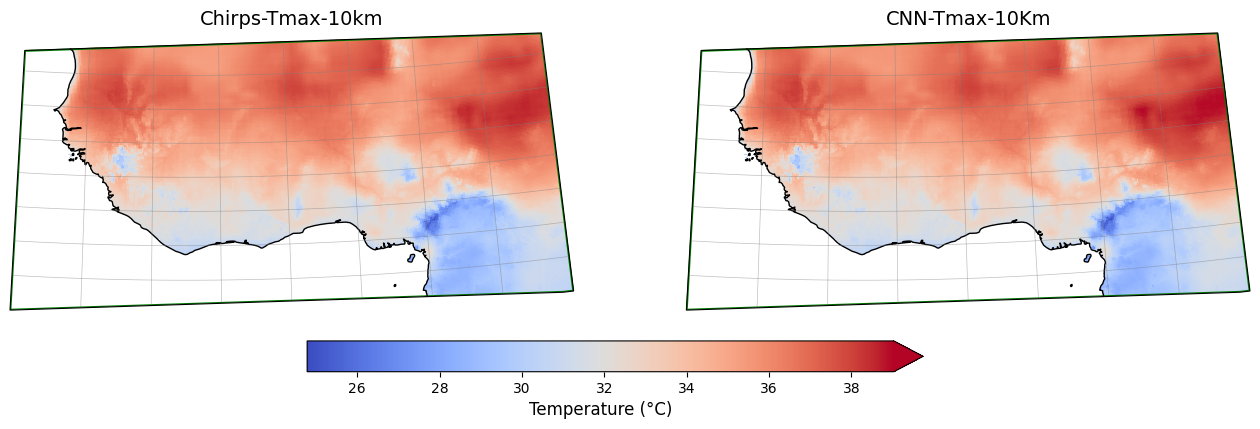

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import numpy as np
import shapely.geometry as sgeom
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# -----------------------------
# Helper: Convert Shapely geometry to a Matplotlib Path
# -----------------------------
def polygon_to_path(geom):
    if geom.is_empty:
        return None

    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        codes = (
            [mpath.Path.MOVETO] +
            [mpath.Path.LINETO] * (len(coords) - 2) +
            [mpath.Path.CLOSEPOLY]
        )
        vertices = np.array(coords, dtype=float)
        return mpath.Path(vertices, codes)

    elif geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        subpaths = []
        for part in geom.geoms:
            p = polygon_to_path(part)
            if p is not None:
                subpaths.append(p)
        if subpaths:
            return mpath.Path.make_compound_path(*subpaths)
        else:
            return None

    return None

# -----------------------------
# LOAD DATA & COMPUTE TIME-MEAN
# -----------------------------
# Replace these with your actual NetCDF filenames and variable names
file1 = 'tmax_test.nc'
file2 = 'tmax_test_cnn.nc'

# Uncomment the following line if using an xarray Dataset;
# here, ds1 is taken from an external source (e.g., y_test) for demonstration.
# ds1 = xr.open_dataset(file1)['Tmax']
ds1 = y_test.Tmax  # Assuming y_test.Tmax is defined in your workspace
ds2 = xr.open_dataset(file2)['Tmax']

ds1_mean = ds1.mean(dim='time')
ds2_mean = ds2.mean(dim='time')

# -----------------------------
# Determine the shared color range from the data
# -----------------------------
vmin_data = float(np.minimum(ds1_mean.min().values, ds2_mean.min().values))
vmax_data = float(np.maximum(ds1_mean.max().values, ds2_mean.max().values))

# -----------------------------
# PLOTTING FUNCTION
# -----------------------------
def plot_mean(data, title, ax, vmin, vmax, cmap):
    """
    Plots a time-mean DataArray on the given Axes using a Lambert Conformal
    projection, clipping to a specified bounding box.
    """
    # Define the bounding box: [lon_min, lon_max, lat_min, lat_max]
    domain_extent = [-20, 20, 0, 19]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    # Create a Shapely box and project it to the current projection
    lon_min, lon_max, lat_min, lat_max = domain_extent
    box_polygon = sgeom.box(lon_min, lat_min, lon_max, lat_max)
    domain_lambert = ax.projection.project_geometry(box_polygon, ccrs.PlateCarree())
    domain_path = polygon_to_path(domain_lambert)
    if domain_path is not None:
        domain_path.should_simplify = False
        ax.set_boundary(domain_path, transform=ax.transData)

    ax.coastlines()

    # Plot the mean data using the specified vmin, vmax, and colormap
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14)

    # Add gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    # Optionally, add a green outline for the bounding box
    if domain_path is not None:
        outline_patch = mpatches.PathPatch(
            domain_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='green',
            linewidth=2
        )
        ax.add_patch(outline_patch)

    return im

# -----------------------------
# MAIN PLOTTING LOGIC
# -----------------------------
# Define a Lambert Conformal projection (centered roughly over the domain)
lambert_proj = ccrs.LambertConformal(
    central_longitude=-7.5,
    central_latitude=12.5,
    standard_parallels=(10, 20)
)

# Create a 1 x 2 grid of subplots
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': lambert_proj}
)

# Use the built-in 'coolwarm' colormap for temperature
im1 = plot_mean(ds1_mean, 'Chirps-Tmax-10km', axes[0], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')
im2 = plot_mean(ds2_mean, 'CNN-Tmax-10Km', axes[1], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')

# Create one shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    fraction=0.05,
    pad=0.05,
    extend='max'
)
cbar.ax.set_xlabel('Temperature (°C)', fontsize=12)

# Save and display the figure
plt.savefig('two_plots_temperature.png', dpi=300)
plt.show()


<ipython-input-33-31cf05cf3469>:163: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  inset_ax.legend(fontsize=8)


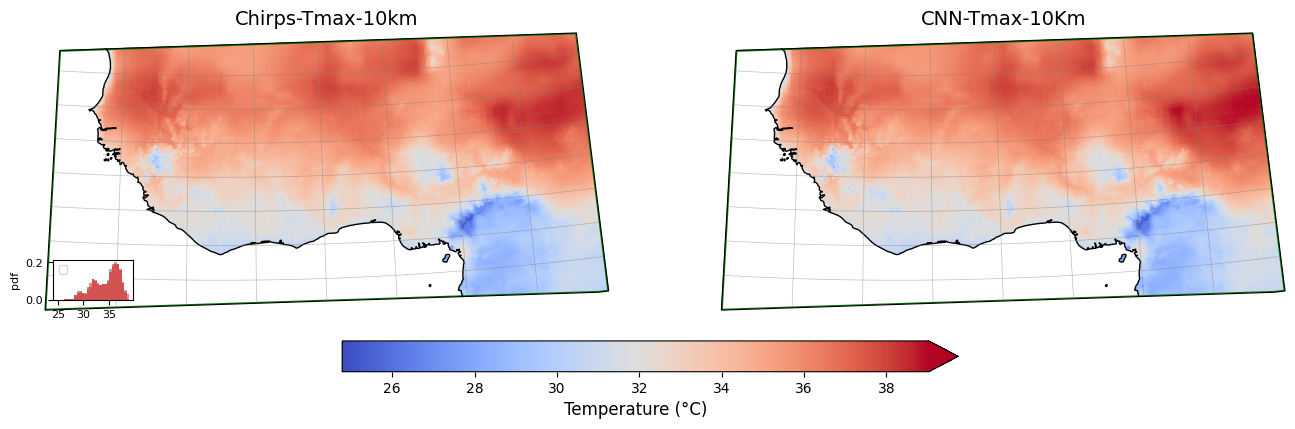

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import numpy as np
import shapely.geometry as sgeom
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# -----------------------------
# Helper: Convert Shapely geometry to a Matplotlib Path
# -----------------------------
def polygon_to_path(geom):
    if geom.is_empty:
        return None

    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        codes = (
            [mpath.Path.MOVETO] +
            [mpath.Path.LINETO] * (len(coords) - 2) +
            [mpath.Path.CLOSEPOLY]
        )
        vertices = np.array(coords, dtype=float)
        return mpath.Path(vertices, codes)

    elif geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        subpaths = []
        for part in geom.geoms:
            p = polygon_to_path(part)
            if p is not None:
                subpaths.append(p)
        if subpaths:
            return mpath.Path.make_compound_path(*subpaths)
        else:
            return None

    return None

# -----------------------------
# LOAD DATA & COMPUTE TIME-MEAN
# -----------------------------
file1 = 'tmax_test.nc'
file2 = 'tmax_test_cnn.nc'

# ds1 = xr.open_dataset(file1)['Tmax']
# ds2 = xr.open_dataset(file2)['Tmax']
# For demonstration, assume ds1 and ds2 are already loaded:
ds1_mean = ds1.mean(dim='time')
ds2_mean = ds2.mean(dim='time')

# -----------------------------
# Determine the shared color range from the data
# -----------------------------
vmin_data = float(np.minimum(ds1_mean.min().values, ds2_mean.min().values))
vmax_data = float(np.maximum(ds1_mean.max().values, ds2_mean.max().values))

# -----------------------------
# PLOTTING FUNCTION
# -----------------------------
def plot_mean(data, title, ax, vmin, vmax, cmap):
    """
    Plots a time-mean DataArray on the given Axes using a Lambert Conformal
    projection, clipping to a specified bounding box.
    """
    # Define the bounding box: [lon_min, lon_max, lat_min, lat_max]
    domain_extent = [-20, 20, 0, 19]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    # Create a Shapely box and project it to the current projection
    lon_min, lon_max, lat_min, lat_max = domain_extent
    box_polygon = sgeom.box(lon_min, lat_min, lon_max, lat_max)
    domain_lambert = ax.projection.project_geometry(box_polygon, ccrs.PlateCarree())
    domain_path = polygon_to_path(domain_lambert)
    if domain_path is not None:
        domain_path.should_simplify = False
        ax.set_boundary(domain_path, transform=ax.transData)

    ax.coastlines()

    # Plot the mean data using the specified vmin, vmax, and colormap
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14)

    # Add gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    # Optional bounding box outline
    if domain_path is not None:
        outline_patch = mpatches.PathPatch(
            domain_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='green',
            linewidth=2
        )
        ax.add_patch(outline_patch)

    return im

# -----------------------------
# MAIN PLOTTING LOGIC
# -----------------------------
lambert_proj = ccrs.LambertConformal(
    central_longitude=-7.5,
    central_latitude=12.5,
    standard_parallels=(10, 20)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': lambert_proj}
)

im1 = plot_mean(ds1_mean, 'Chirps-Tmax-10km', axes[0], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')
im2 = plot_mean(ds2_mean, 'CNN-Tmax-10Km', axes[1], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')

# One shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    fraction=0.05,
    pad=0.05,
    extend='max'
)
cbar.ax.set_xlabel('Temperature (°C)', fontsize=12)

# ----------------------------------------------------
# ADD A SMALLER INSET AXIS WITH TWO PDFS
# ----------------------------------------------------
# Adjust the [x, y, width, height] to make it smaller
inset_ax = fig.add_axes([0.13, 0.20, 0.05, 0.05])  # Adjust as needed

# Prepare data
vals1 = ds1_mean.values.flatten()
vals1 = vals1[~np.isnan(vals1)]
vals2 = ds2_mean.values.flatten()
vals2 = vals2[~np.isnan(vals2)]

# Common bin edges (adjust as desired)
bins = np.linspace(vmin_data, vmax_data, 30)

# Plot histograms for both Observed and Model
inset_ax.hist(vals1, bins=bins, density=True, color='gray', alpha=0.7)
inset_ax.hist(vals2, bins=bins, density=True, color='red', alpha=0.5)

#inset_ax.set_xlabel('Tmax (°C)', fontsize=3)
inset_ax.set_ylabel('pdf', fontsize=8)
inset_ax.tick_params(axis='both', labelsize=8)
inset_ax.legend(fontsize=8)

# (Optional) set x-limits to something like 20–40 if your data are narrower:
# inset_ax.set_xlim(20, 40)

plt.savefig('two_plots_temperature_with_both_pdfs.png', dpi=300)
plt.show()


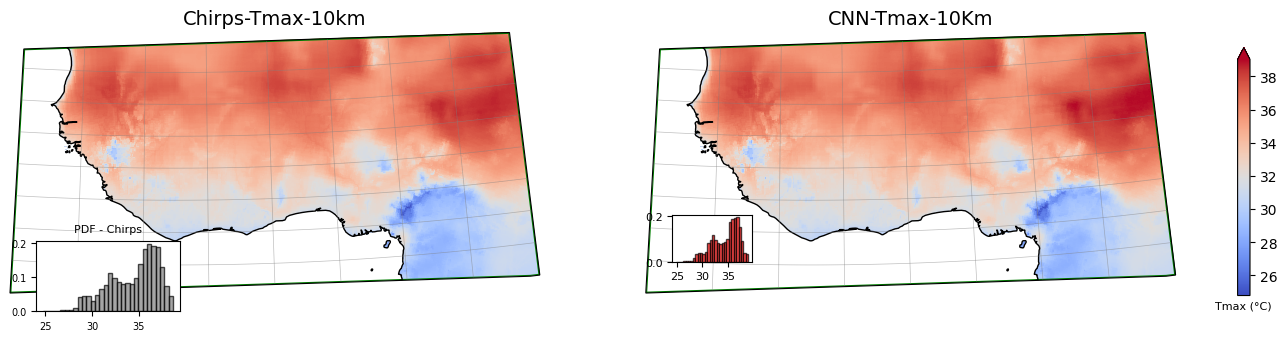

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import numpy as np
import shapely.geometry as sgeom
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# For creating inset axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -----------------------------
# Helper: Convert Shapely geometry to a Matplotlib Path
# -----------------------------
def polygon_to_path(geom):
    if geom.is_empty:
        return None

    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        codes = (
            [mpath.Path.MOVETO] +
            [mpath.Path.LINETO] * (len(coords) - 2) +
            [mpath.Path.CLOSEPOLY]
        )
        vertices = np.array(coords, dtype=float)
        return mpath.Path(vertices, codes)

    elif geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        subpaths = []
        for part in geom.geoms:
            p = polygon_to_path(part)
            if p is not None:
                subpaths.append(p)
        if subpaths:
            return mpath.Path.make_compound_path(*subpaths)
        else:
            return None

    return None

# -----------------------------
# LOAD DATA & COMPUTE TIME-MEAN
# -----------------------------
file1 = 'tmax_test.nc'
file2 = 'tmax_test_cnn.nc'

# ds1 = xr.open_dataset(file1)['Tmax']
# ds2 = xr.open_dataset(file2)['Tmax']
# For demonstration, assume ds1 and ds2 are already loaded:
ds1_mean = ds1.mean(dim='time')
ds2_mean = ds2.mean(dim='time')

# -----------------------------
# Determine the shared color range from the data
# -----------------------------
vmin_data = float(np.minimum(ds1_mean.min().values, ds2_mean.min().values))
vmax_data = float(np.maximum(ds1_mean.max().values, ds2_mean.max().values))

# -----------------------------
# PLOTTING FUNCTION
# -----------------------------
def plot_mean(data, title, ax, vmin, vmax, cmap):
    """
    Plots a time-mean DataArray on the given Axes using a Lambert Conformal
    projection, clipping to a specified bounding box.
    """
    # Define the bounding box: [lon_min, lon_max, lat_min, lat_max]
    domain_extent = [-20, 20, 0, 19]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    # Create a Shapely box and project it to the current projection
    lon_min, lon_max, lat_min, lat_max = domain_extent
    box_polygon = sgeom.box(lon_min, lat_min, lon_max, lat_max)
    domain_lambert = ax.projection.project_geometry(box_polygon, ccrs.PlateCarree())
    domain_path = polygon_to_path(domain_lambert)
    if domain_path is not None:
        domain_path.should_simplify = False
        ax.set_boundary(domain_path, transform=ax.transData)

    ax.coastlines()

    # Plot the mean data using the specified vmin, vmax, and colormap
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14)

    # Add gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    # Optional bounding box outline
    if domain_path is not None:
        outline_patch = mpatches.PathPatch(
            domain_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='green',
            linewidth=2
        )
        ax.add_patch(outline_patch)

    return im

# -----------------------------
# MAIN PLOTTING LOGIC
# -----------------------------
lambert_proj = ccrs.LambertConformal(
    central_longitude=-7.5,
    central_latitude=12.5,
    standard_parallels=(10, 20)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': lambert_proj}
)

# Plot each map
im1 = plot_mean(ds1_mean, 'Chirps-Tmax-10km', axes[0], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')
im2 = plot_mean(ds2_mean, 'CNN-Tmax-10Km', axes[1], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')

# Shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    orientation='vertical',
    fraction=0.01,
    #shrink=0.8,
    pad=0.05,
    extend='max'
)
cbar.ax.set_xlabel('Tmax (°C)', fontsize=8)

# ----------------------------------------------------
# INSET 1: PDF for ds1 (Observed/Chirps)
# ----------------------------------------------------
# Place a small inset in the coordinate space of axes[0]
inset_ax1 = inset_axes(
    axes[0],
    width="30%",  # 30% of the parent axis width
    height="30%", # 30% of the parent axis height
    loc='upper left',  # you can change to 'lower left', etc.
    # The bbox_to_anchor and bbox_transform define how to position the inset
    bbox_to_anchor=(0.05, -0.7, 0.9, 0.9),
    bbox_transform=axes[0].transAxes,
    borderpad=0
)

vals1 = ds1_mean.values.flatten()
vals1 = vals1[~np.isnan(vals1)]

# Create a histogram for Chirps
inset_ax1.hist(
    vals1,
    bins=30,
    density=True,
    color='gray',
    edgecolor='black',
    alpha=0.7
)
inset_ax1.set_title('PDF - Chirps', fontsize=8)
inset_ax1.set_xlabel('', fontsize=7)
inset_ax1.set_ylabel('', fontsize=7)
inset_ax1.tick_params(axis='both', labelsize=7)

# ----------------------------------------------------
# INSET 2: PDF for ds2 (Model/CNN)
# ----------------------------------------------------
# Place a small inset in the coordinate space of axes[1]
inset_ax2 = inset_axes(
    axes[1],
    width="30%",
    height="30%",
    loc='upper left',
    bbox_to_anchor=(0.05, -0.3, 0.5, 0.6),
    bbox_transform=axes[1].transAxes,
    borderpad=0
)

vals2 = ds2_mean.values.flatten()
vals2 = vals2[~np.isnan(vals2)]

# Create a histogram for CNN
inset_ax2.hist(
    vals2,
    bins=30,
    density=True,
    color='red',
    edgecolor='black',
    alpha=0.7
)
inset_ax2.set_title('', fontsize=8)
#inset_ax2.set_xlabel('Tmax (°C)', fontsize=7)
inset_ax2.set_ylabel('', fontsize=7)
inset_ax2.tick_params(axis='both', labelsize=8)

# Save and display
plt.savefig('two_plots_temperature_with_two_inset_pdfs.png', dpi=300)
plt.show()

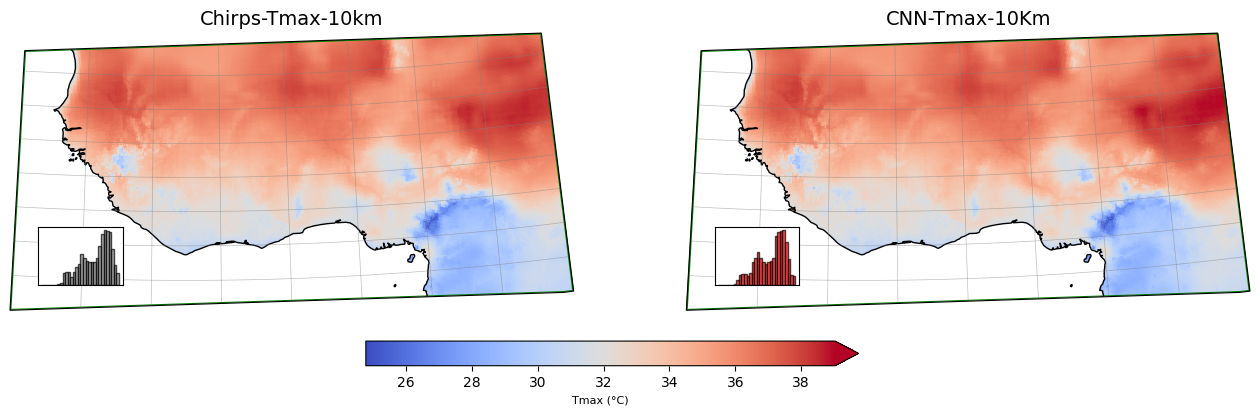

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xarray as xr
import numpy as np
import shapely.geometry as sgeom
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# For creating inset axes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def polygon_to_path(geom):
    if geom.is_empty:
        return None

    if geom.geom_type == 'Polygon':
        coords = list(geom.exterior.coords)
        codes = (
            [mpath.Path.MOVETO] +
            [mpath.Path.LINETO] * (len(coords) - 2) +
            [mpath.Path.CLOSEPOLY]
        )
        vertices = np.array(coords, dtype=float)
        return mpath.Path(vertices, codes)

    elif geom.geom_type in ['MultiPolygon', 'GeometryCollection']:
        subpaths = []
        for part in geom.geoms:
            p = polygon_to_path(part)
            if p is not None:
                subpaths.append(p)
        if subpaths:
            return mpath.Path.make_compound_path(*subpaths)
        else:
            return None

    return None

file1 = 'tmax_test.nc'
file2 = 'tmax_test_cnn.nc'

# ds1 = xr.open_dataset(file1)['Tmax']
# ds2 = xr.open_dataset(file2)['Tmax']
# For demonstration, assume ds1 and ds2 are already loaded:
ds1_mean = ds1.mean(dim='time')
ds2_mean = ds2.mean(dim='time')

vmin_data = float(np.minimum(ds1_mean.min().values, ds2_mean.min().values))
vmax_data = float(np.maximum(ds1_mean.max().values, ds2_mean.max().values))

def plot_mean(data, title, ax, vmin, vmax, cmap):
    domain_extent = [-20, 20, 0, 19]
    ax.set_extent(domain_extent, crs=ccrs.PlateCarree())

    lon_min, lon_max, lat_min, lat_max = domain_extent
    box_polygon = sgeom.box(lon_min, lat_min, lon_max, lat_max)
    domain_lambert = ax.projection.project_geometry(box_polygon, ccrs.PlateCarree())
    domain_path = polygon_to_path(domain_lambert)
    if domain_path is not None:
        domain_path.should_simplify = False
        ax.set_boundary(domain_path, transform=ax.transData)

    ax.coastlines()

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.set_title(title, fontsize=14)

    gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    if domain_path is not None:
        outline_patch = mpatches.PathPatch(
            domain_path,
            transform=ax.transData,
            facecolor='none',
            edgecolor='green',
            linewidth=2
        )
        ax.add_patch(outline_patch)

    return im

lambert_proj = ccrs.LambertConformal(
    central_longitude=-7.5,
    central_latitude=12.5,
    standard_parallels=(10, 20)
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={'projection': lambert_proj}
)

im1 = plot_mean(ds1_mean, 'Chirps-Tmax-10km', axes[0], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')
im2 = plot_mean(ds2_mean, 'CNN-Tmax-10Km', axes[1], vmin=vmin_data, vmax=vmax_data, cmap='coolwarm')

cbar = fig.colorbar(
    im2,
    ax=axes.ravel().tolist(),
    orientation='horizontal',
    fraction=0.04,
    pad=0.05,
    extend='max'
)
cbar.ax.set_xlabel('Tmax (°C)', fontsize=8)

# ----------------------------------------------------
# INSET 1: PDF for ds1 (Observed/Chirps)
# ----------------------------------------------------
inset_ax1 = inset_axes(
    axes[0],
    width="30%",
    height="30%",
    loc='upper left',
    bbox_to_anchor=(0.05, -0.4, 0.5, 0.7),
    bbox_transform=axes[0].transAxes,
    borderpad=0
)

vals1 = ds1_mean.values.flatten()
vals1 = vals1[~np.isnan(vals1)]

inset_ax1.hist(
    vals1,
    bins=30,
    density=True,
    color='gray',
    edgecolor='black',
    alpha=0.7
)
#inset_ax1.set_title('PDF - Chirps', fontsize=8)

# Remove x/y ticks entirely
inset_ax1.set_xticks([])
inset_ax1.set_yticks([])

# ----------------------------------------------------
# INSET 2: PDF for ds2 (Model/CNN)
# ----------------------------------------------------
inset_ax2 = inset_axes(
    axes[1],
    width="30%",
    height="30%",
    loc='upper left',
    bbox_to_anchor=(0.05, -0.4, 0.5, 0.7),
    bbox_transform=axes[1].transAxes,
    borderpad=0
)

vals2 = ds2_mean.values.flatten()
vals2 = vals2[~np.isnan(vals2)]

inset_ax2.hist(
    vals2,
    bins=30,
    density=True,
    color='red',
    edgecolor='black',
    alpha=0.7
)
# No title, just hide ticks
inset_ax2.set_xticks([])
inset_ax2.set_yticks([])

plt.savefig('two_plots_temperature_with_two_inset_pdfs.png', dpi=300)
plt.show()
